__Install library yang di butuhkan__
- wordsegment 
- tensoflow
- keras
<br>
[reference]('[text](https://www-projectpro-io.translate.goog/article/how-to-build-an-nlp-model-step-by-step-using-python/915?_x_tr_sl=en&_x_tr_tl=id&_x_tr_hl=id&_x_tr_pto=tc)')
<br>
Teknik NLP meliputi tokenisasi, penandaan bagian-of-speech, pengenalan entitas bernama, analisis sentimen, penerjemahan mesin, pemodelan topik, dan banyak lagi, yang memfasilitasi berbagai tugas analisis dan pemahaman teks.

In [8]:
import nltk
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
from nltk import word_tokenize , sent_tokenize

# donload model 
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download("stopword")
nltk.download('punkt_tab')

from nltk.corpus import stopwords

[nltk_data] Downloading package wordnet to /home/dar05/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/dar05/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Error loading stopword: Package 'stopword' not found in
[nltk_data]     index
[nltk_data] Downloading package punkt_tab to /home/dar05/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Siapkan __Dataset__ Input
 persiapan set data masukan dengan mengambil data tersebut dari situs web.  Set data sampel berisi 10.000 twit dengan label di sebelahnya.

In [9]:
# training_url = "https://raw.githubusercontent.com/teyang-lau/Disaster_Tweet_Classification/master/data/train.csv" # sudah tidak di temukan
# test_url = "https://raw.githubusercontent.com/teyang-lau/Disaster_Tweet_Classification/master/data/test.csv"
training_data = "./dataset-training-fake-nlp.csv"
test_data = "./dataset-test-fake-nlp.csv"

train = pd.read_csv(training_data)
test = pd.read_csv(test_data)
# print(train.head(n=5))

**Analisis Data Eksplorasi (EDA)**
Exploirasi dan amati , dataset

<Axes: >

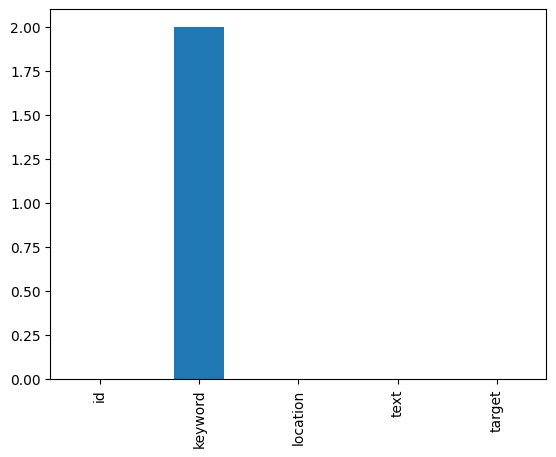

In [10]:
train.isnull().sum().plot(kind='bar')

 Selami eksplorasi frekuensi karakter, kata, dan kalimat yang berbeda.

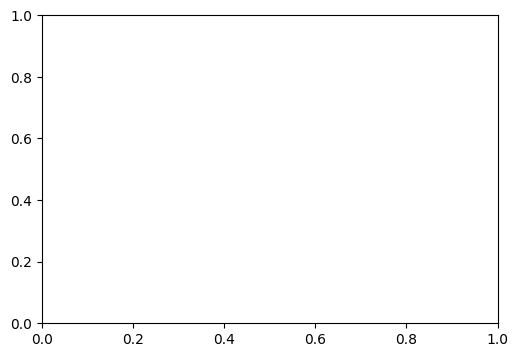

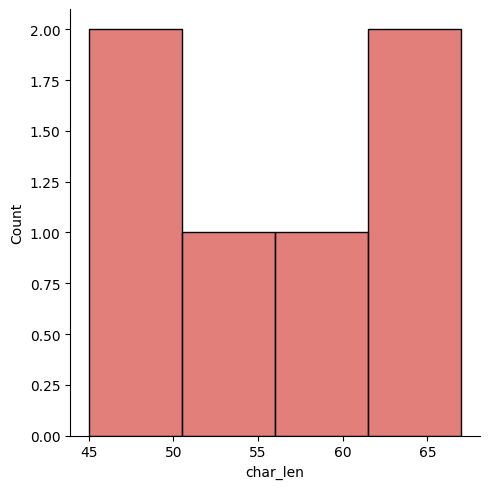

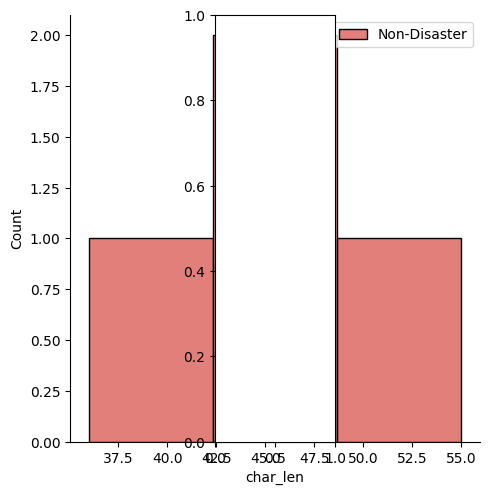

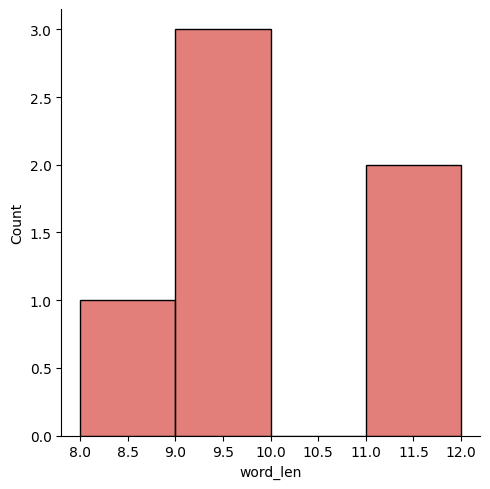

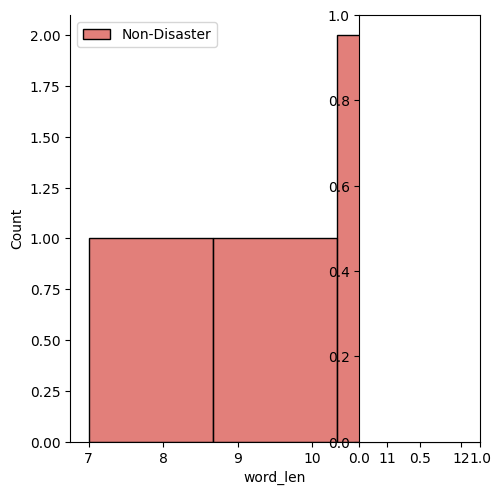

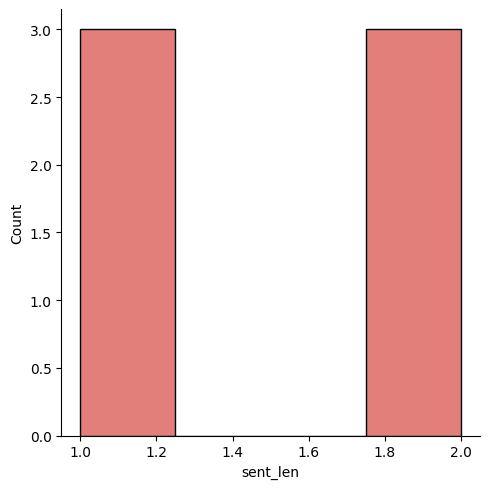

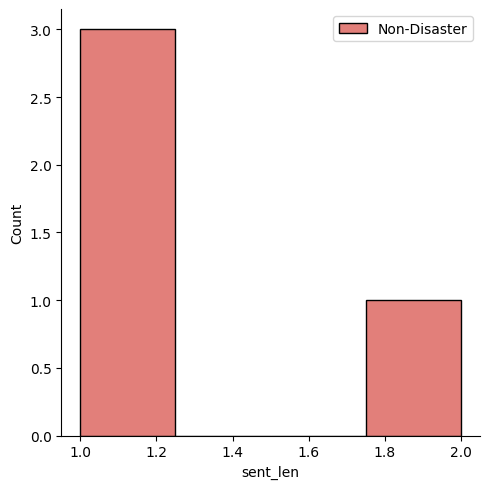

In [17]:
#hitung jumlah karakter di setiap tweet
train['char_len'] = train.text.str.len()
# hitung jumlah kata di setiap tweet
word_tokens = [len(word_tokenize(var)) for var in train.text]
train['word_len'] = word_tokens

# hitung jumlah kalimat di setiap tweet
sent_tokent = [len(sent_tokenize(var)) for var in train.text]
train['sent_len'] = sent_tokent

plot_cols = ['char_len','word_len','sent_len']
plot_title = ["Character len","word len","sentance lenght"]
color = [sns.xkcd_rgb["medium blue"],sns.xkcd_rgb['pale red']]

#tampilkan
plt.figure(figsize=(20,4))
for counter , index in enumerate([0,1,2]):
    plt.subplot(1,3,counter +1)
    sns.displot(train[train.target == 1][plot_cols[index]] ,label='Disanter',color=color[1]).set_titles(plot_title[index])
    sns.displot(train[train.target == 0][plot_cols[index]] , label='Non-Disaster',color=color[1])
    plt.legend()


Jika ada beberapa Outlier seperti terdapat **tweet** dengan panjang kalimat > 7 dan panjang kata > 55, harus di selidiki

grafik dan lihat kata-kata henti yang paling umum dalam teks

In [ ]:
stop = set(stopwords.word('english'))

# dapatkan semua token dalam dataframe untuk Disaster atau non Disaster
corpus0  = []
[corpus0.append(word.lower()) for word in train[train.target == 0].text for word in word_tokenize(var)]
corpus1  = []
[corpus0.append(word.lower()) for word in train[train.target == 1].text for word in word_tokenize(var)]